In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
foods = pd.read_csv('../data/processed/foods_cleaned.csv')

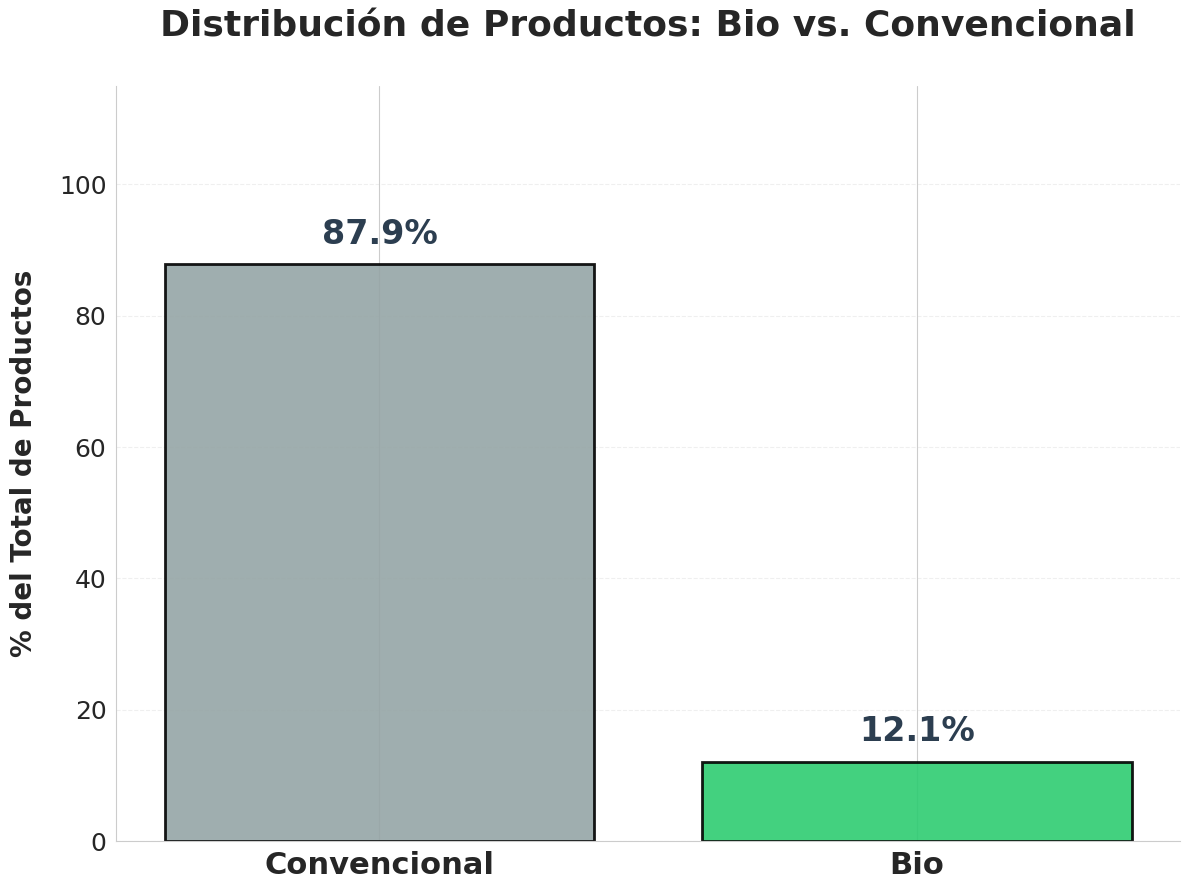

In [80]:
# --- 1. PREPARACIÓN DE DATOS  ---
plot_series = foods['is_bio'].map({
    True: 'Bio', False: 'Convencional',
    'true': 'Bio', 'false': 'Convencional',
    '1': 'Bio', '0': 'Convencional',
    'Bio': 'Bio', 'Convencional': 'Convencional' # Añadimos esto por si ya estaba transformado
}).fillna('Convencional')

# Cálculos estadísticos sobre la serie temporal
counts = plot_series.value_counts()
percentages = (counts / len(foods) * 100)

# Aseguramos un orden fijo para que los colores no bailen (Convencional primero, Bio después)
order = ['Convencional', 'Bio']
percentages = percentages.reindex(order).fillna(0)
counts = counts.reindex(order).fillna(0)

# --- 2. VISUALIZACIÓN ---
plt.figure(figsize=(12, 9))
colors = ['#95a5a6', '#2ecc71'] 

bars = plt.bar(
    percentages.index, 
    percentages.values, 
    color=colors, 
    edgecolor='black', 
    linewidth=2,
    alpha=0.9
)

# --- 3. ESTÉTICA Y FUENTES MAXIMIZADAS ---
plt.title('Distribución de Productos: Bio vs. Convencional', fontsize=26, fontweight='bold', pad=35)
plt.ylabel('% del Total de Productos', fontsize=20, fontweight='bold', labelpad=15)
plt.xticks(fontsize=22, fontweight='bold')
plt.yticks(fontsize=18)

plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.3)

# --- 4. ANOTACIONES (PORCENTAJES Y N) ---
for i, bar in enumerate(bars):
    pct = percentages.values[i]
    n_total = int(counts.values[i])
    
    # Porcentaje arriba (Muy grande)
    plt.text(
        bar.get_x() + bar.get_width()/2, 
        bar.get_height() + 2, 
        f'{pct:.1f}%', 
        ha='center', va='bottom', 
        fontsize=24, fontweight='bold', color='#2c3e50'
    )
    
sns.despine()
plt.tight_layout()

# --- 5. GUARDAR ---
plt.savefig('../images/02_h02/2.1_distribucion_bio.png', bbox_inches='tight', dpi=300)
plt.show()

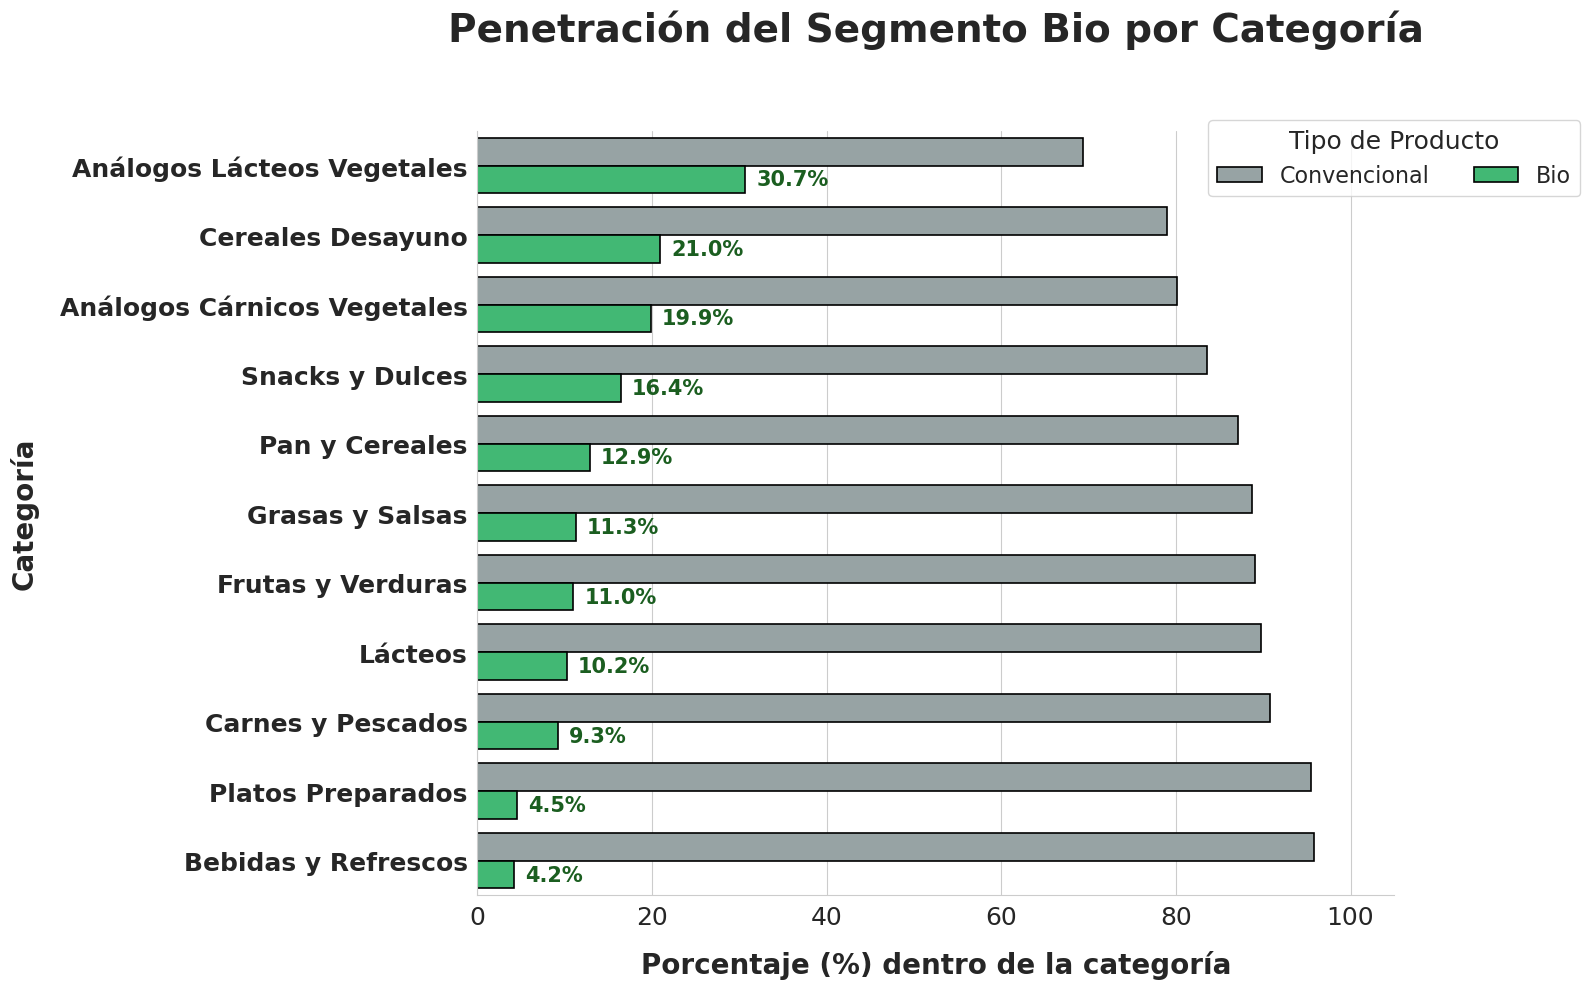

In [81]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. DICCIONARIO DE TRADUCCIÓN  ---
traduccion_cat = {
    "beverage": "Bebidas y Refrescos",
    "dairy_eggs": "Lácteos",
    "meat_fish": "Carnes y Pescados",
    "fats_sauces": "Grasas y Salsas",
    "snacks_sweets": "Snacks y Dulces",
    "plant_based": "Frutas y Verduras",
    "plant_based_protein": "Análogos Cárnicos Vegetales",
    "plant_based_milks": "Análogos Lácteos Vegetales",
    "bread_and_grains": "Pan y Cereales",
    "ready_to_eat": "Platos Preparados",
    "breakfast_cereals": "Cereales Desayuno"
}

# --- 2. PREPARACIÓN DE DATOS ---
# Aplicamos la traducción
foods["category_es"] = foods["category_unified"].map(traduccion_cat).fillna(foods["category_unified"])

# Seleccionamos las categorías de tu lista (puedes ajustar el top_n si quieres menos)
top_categorias = foods["category_es"].value_counts().index
df_top = foods[foods["category_es"].isin(top_categorias)].copy()

# Tabla cruzada con porcentajes (Bio vs Convencional)
cross_tab = pd.crosstab(
    df_top["category_es"], 
    df_top["is_bio"], 
    normalize="index"
) * 100

# Ordenamos para que la categoría con más % Bio esté arriba
cross_tab = cross_tab.sort_values(by=True, ascending=False)

# Formato largo para Seaborn
plot_df = cross_tab.reset_index().melt(id_vars="category_es", var_name="tipo_bio", value_name="porcentaje")
plot_df["tipo_label"] = plot_df["tipo_bio"].map({True: "Bio", False: "Convencional"})

# --- 3. VISUALIZACIÓN PROFESIONAL ---
plt.figure(figsize=(16, 10))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=plot_df,
    y="category_es",
    x="porcentaje",
    hue="tipo_label",
    palette={"Bio": "#2ecc71", "Convencional": "#95a5a6"},
    edgecolor="black",
    linewidth=1.2
)

# --- 4. FUENTES Y ESTÉTICA (MAXIMIZADAS) ---
plt.title("Penetración del Segmento Bio por Categoría", fontsize=28, fontweight="bold", pad=65)
plt.xlabel("Porcentaje (%) dentro de la categoría", fontsize=20, fontweight="bold", labelpad=15)
plt.ylabel("Categoría", fontsize=20, fontweight="bold", labelpad=15)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18, fontweight="bold")

# Leyenda 
plt.legend(
    title="Tipo de Producto", 
    title_fontsize=18, 
    fontsize=16, 
    loc='lower center', 
    bbox_to_anchor=(1, 0.9), 
    ncol=2, 
    frameon=True
)

# Etiquetas de valor sobre barras Bio
for p in ax.patches:
    width = p.get_width()
    if width < 45 and width > 0: 
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.), 
                    ha='left', va='center', 
                    xytext=(8, 0), 
                    textcoords='offset points', 
                    fontsize=15, fontweight='bold', color='#1b5e20')

plt.xlim(0, 105)
sns.despine()
plt.tight_layout()

# --- 5. GUARDAR ---
plt.savefig('../images/02_h02/2.2_bio_por_categoria.png', bbox_inches='tight', dpi=300)
plt.show()

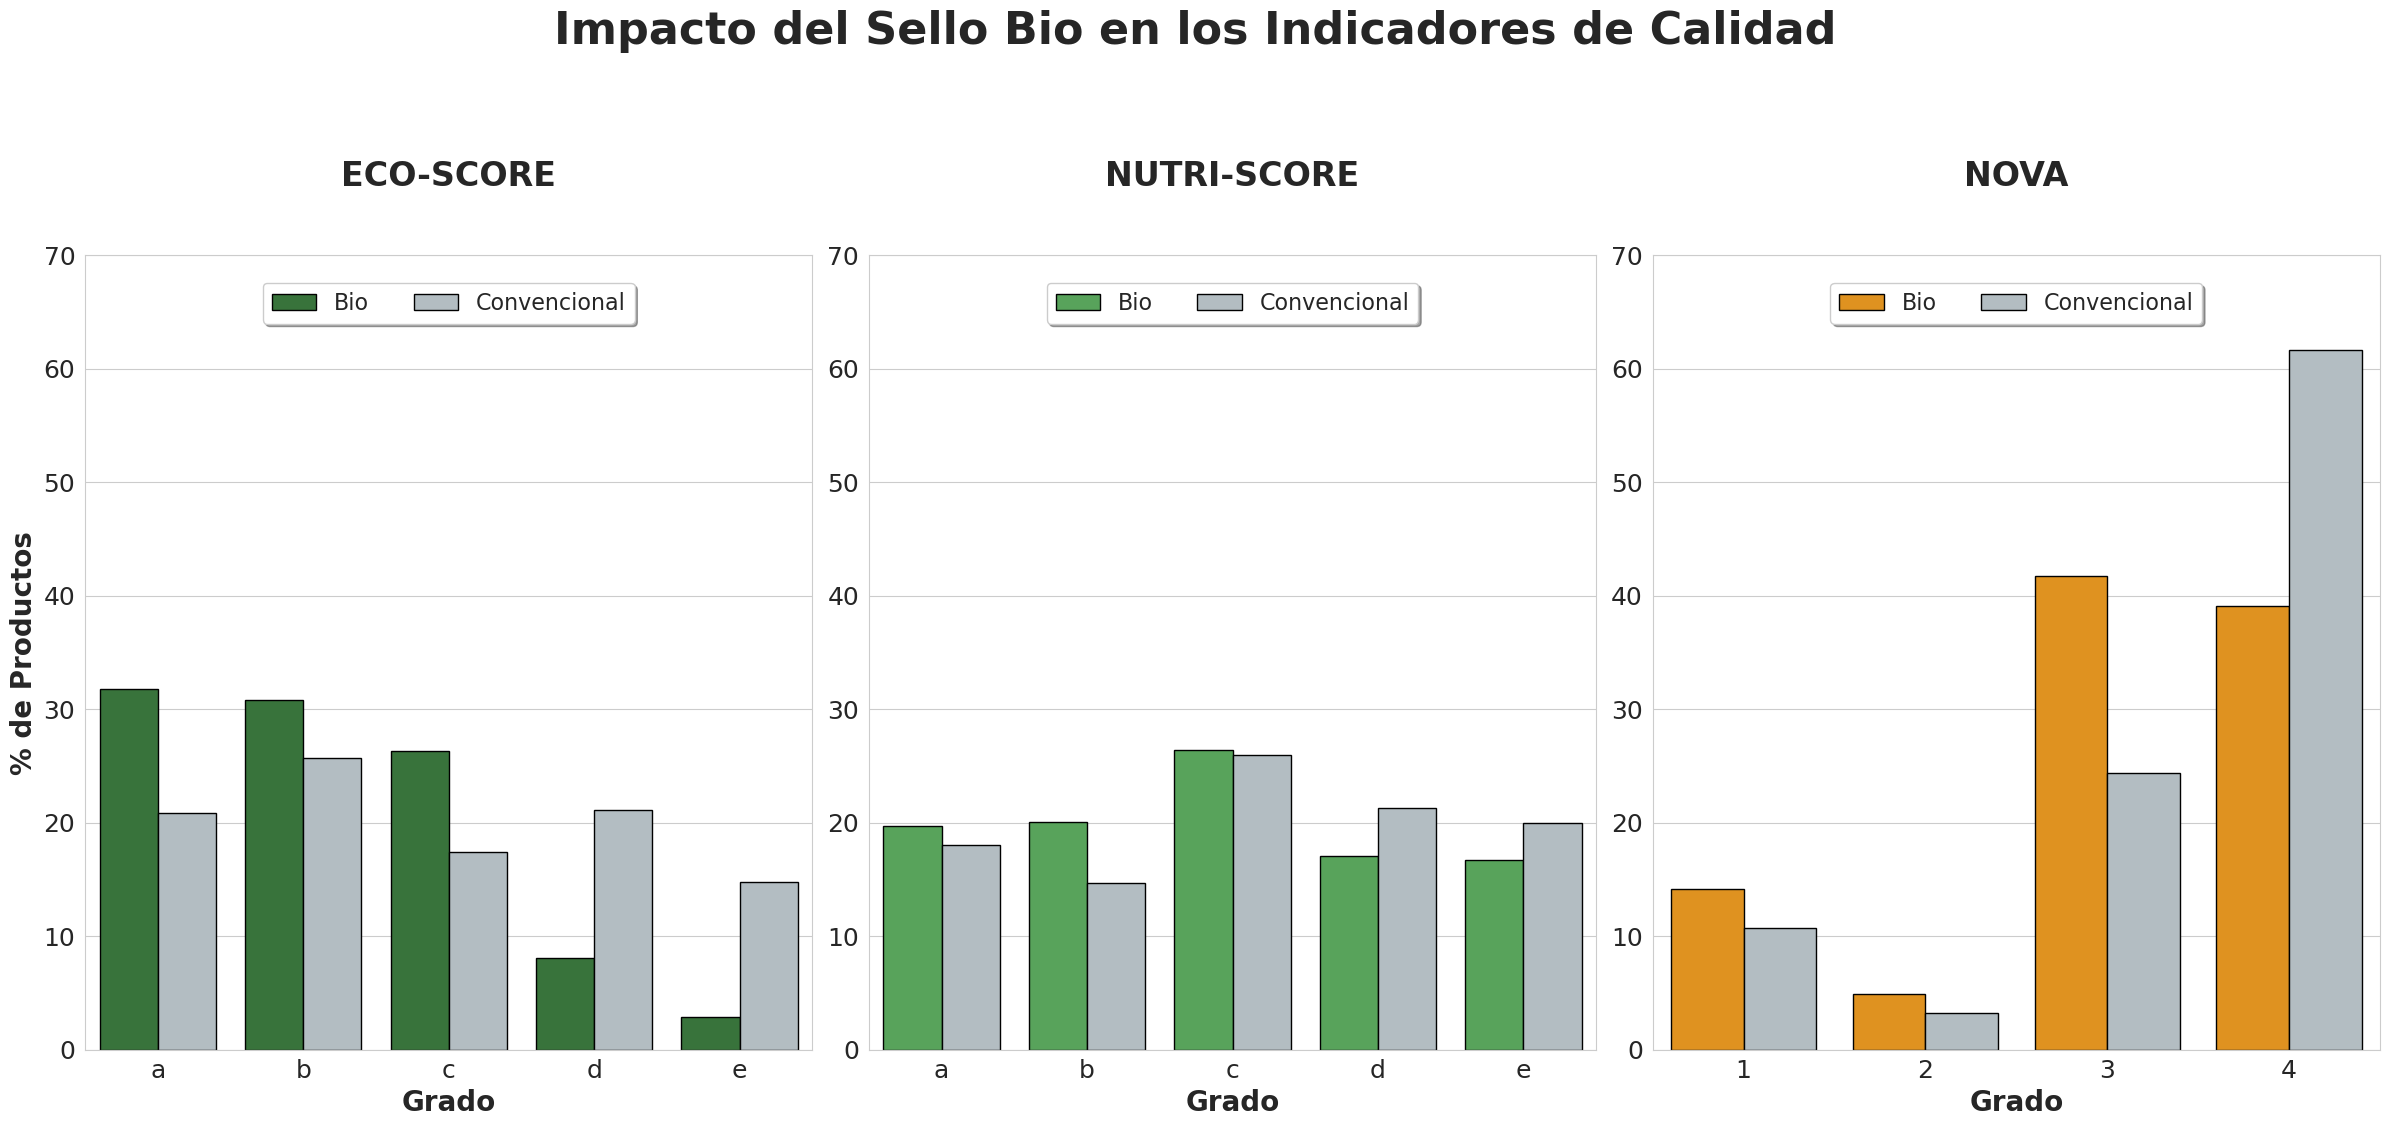

In [82]:
# --- 1. CONFIGURACIÓN DE ÓRDENES Y COLORES ---
order_ns = ['a', 'b', 'c', 'd', 'e']
order_nova = [1, 2, 3, 4]
order_eco = ['a', 'b', 'c', 'd', 'e']

# Paletas personalizadas: Gris para Convencional, Color para Bio
paleta_ns = {"Convencional": "#B0BEC5", "Bio": "#4CAF50"} # Gris azulado vs Verde
paleta_nova = {"Convencional": "#B0BEC5", "Bio": "#FF9800"} # Gris azulado vs Naranja
paleta_eco = {"Convencional": "#B0BEC5", "Bio": "#2E7D32"} # Gris azulado vs Verde Oscuro

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(24, 11)) 

# Función para procesar los datos (Mantenemos la lógica robusta)
def get_melted_data(df, col_name, order_list):
    sub = df[df[col_name].isin(order_list)].copy()
    sub['Tipo'] = sub['is_bio'].map({True: 'Bio', False: 'Convencional'})
    pct = pd.crosstab(sub['Tipo'], sub[col_name], normalize='index') * 100
    return pct.reindex(columns=order_list).fillna(0).reset_index().melt(
        id_vars='Tipo', value_name='pct', var_name='grade'
    )

# --- 2. GENERACIÓN DE LOS 3 GRÁFICOS ---

# Subplot 1: ECO-SCORE
melt_eco = get_melted_data(foods, 'ecoscore_grade', order_eco)
sns.barplot(ax=axes[0], data=melt_eco, x='grade', y='pct', hue='Tipo', palette=paleta_eco, edgecolor='black')
axes[0].set_title("ECO-SCORE", fontsize=24, fontweight='bold', pad=50)

# Subplot 2: NUTRI-SCORE
melt_ns = get_melted_data(foods, 'nutriscore_grade', order_ns)
sns.barplot(ax=axes[1], data=melt_ns, x='grade', y='pct', hue='Tipo', palette=paleta_ns, edgecolor='black')
axes[1].set_title("NUTRI-SCORE", fontsize=24, fontweight='bold', pad=50)

# Subplot 3: NOVA
melt_nova = get_melted_data(foods, 'nova_group', order_nova)
sns.barplot(ax=axes[2], data=melt_nova, x='grade', y='pct', hue='Tipo', palette=paleta_nova, edgecolor='black')
axes[2].set_title("NOVA", fontsize=24, fontweight='bold', pad=50)

# --- 3. AJUSTE DE LEYENDAS Y EJES ---
for i, ax in enumerate(axes):
    ax.set_ylabel("% de Productos" if i == 0 else "", fontsize=20, fontweight='bold')
    ax.set_xlabel("Grado", fontsize=20, fontweight='bold')
    ax.tick_params(labelsize=18)
    ax.set_ylim(0, 70) # Aumentamos el límite para dar aire a la leyenda
    
    # Leyenda más arriba y centrada
    ax.legend(
        title="", 
        fontsize=16, 
        loc='lower center', 
        bbox_to_anchor=(0.5, 0.9), # Subimos de 1.02 a 1.08 para que flote más arriba
        ncol=2, 
        frameon=True,
        shadow=True
    )

# Título Principal
plt.suptitle("Impacto del Sello Bio en los Indicadores de Calidad", 
             fontsize=32, fontweight='bold', y=1.02)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Ajustamos el área de dibujo para dejar sitio al supertítulo

# --- 4. GUARDAR ---
plt.savefig('../images/02_h02/2.3_analisis_global_bio.png', bbox_inches='tight', dpi=300)
plt.show()

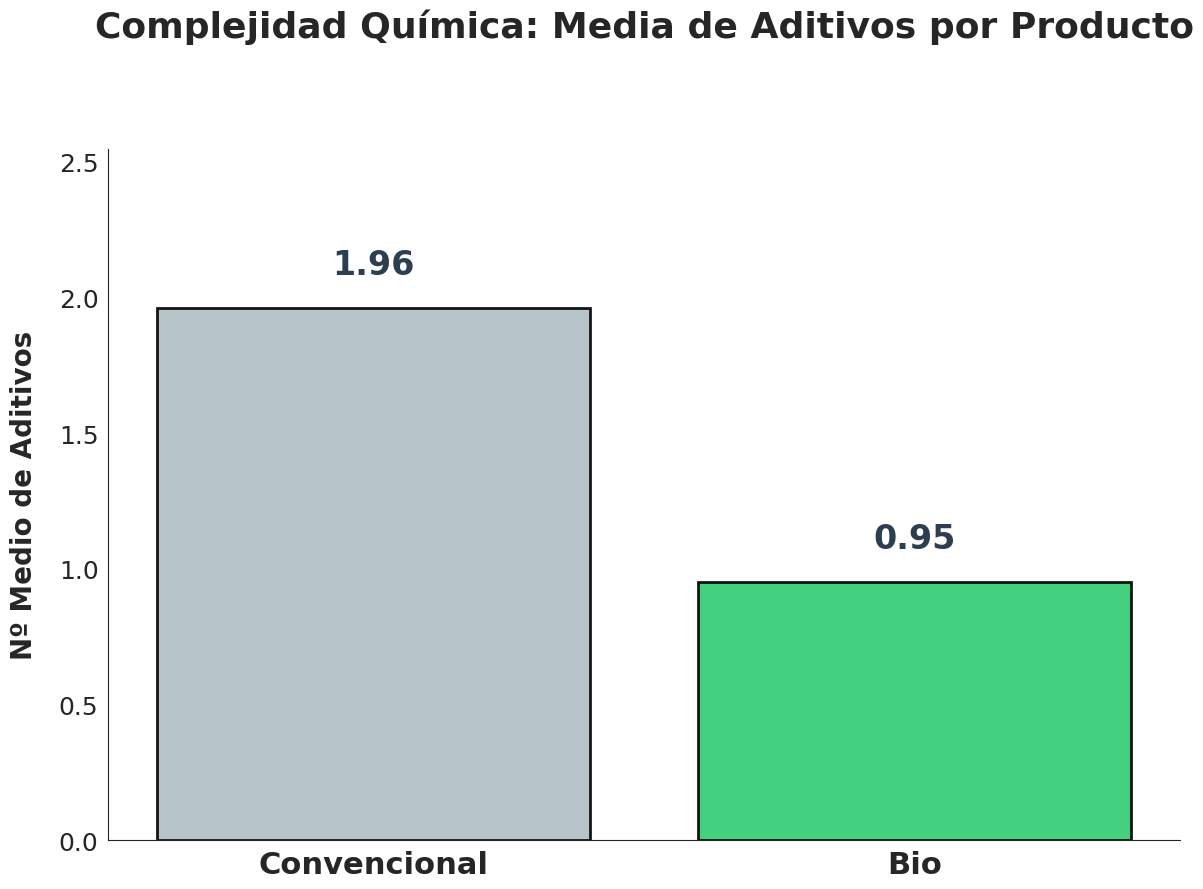

In [83]:

# --- 1. PREPARACIÓN DE DATOS 
df_stats = foods.copy()
df_stats['additive_count'] = pd.to_numeric(df_stats['additive_count'], errors='coerce').fillna(0)

# Agrupamos y calculamos (Usamos el booleano real para evitar errores)
stats = df_stats.groupby('is_bio')['additive_count'].agg(['mean', 'median', 'count']).round(2)

# Extraemos valores para facilitar el dibujo
media_conv = stats.loc[False, 'mean']
media_bio = stats.loc[True, 'mean']
mediana_conv = stats.loc[False, 'median']
mediana_bio = stats.loc[True, 'median']

labels = ['Convencional', 'Bio']
medias = [media_conv, media_bio]

# --- 2. VISUALIZACIÓN PROFESIONAL ---
plt.figure(figsize=(12, 9))
sns.set_style("white")

# Colores: Gris para convencional, Verde para Bio
colors = ['#B0BEC5', '#2ecc71'] 

bars = plt.bar(labels, medias, color=colors, edgecolor='black', linewidth=2, alpha=0.9)

# --- 3. ESTÉTICA Y FUENTES (MAXIMIZADAS) ---
plt.title('Complejidad Química: Media de Aditivos por Producto', fontsize=26, fontweight='bold', pad=80)
plt.ylabel('Nº Medio de Aditivos', fontsize=20, fontweight='bold', labelpad=15)
plt.xticks(fontsize=22, fontweight='bold')
plt.yticks(fontsize=18)

# Ajuste de límites para que las etiquetas respiren
plt.ylim(0, max(medias) * 1.3)
sns.despine()

# --- 4. ANOTACIONES (VALORES Y N) ---
for i, bar in enumerate(bars):
    valor = medias[i]
    n_total = int(stats.iloc[i]['count'])
    
    # Valor medio arriba (Grande)
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{valor:.2f}', ha='center', va='bottom', 
             fontsize=24, fontweight='bold', color='#2c3e50')
    

plt.tight_layout()

# --- 5. GUARDAR ---
plt.savefig('../images/02_h02/2.4_media_aditivos_bio.png', bbox_inches='tight', dpi=300)
plt.show()

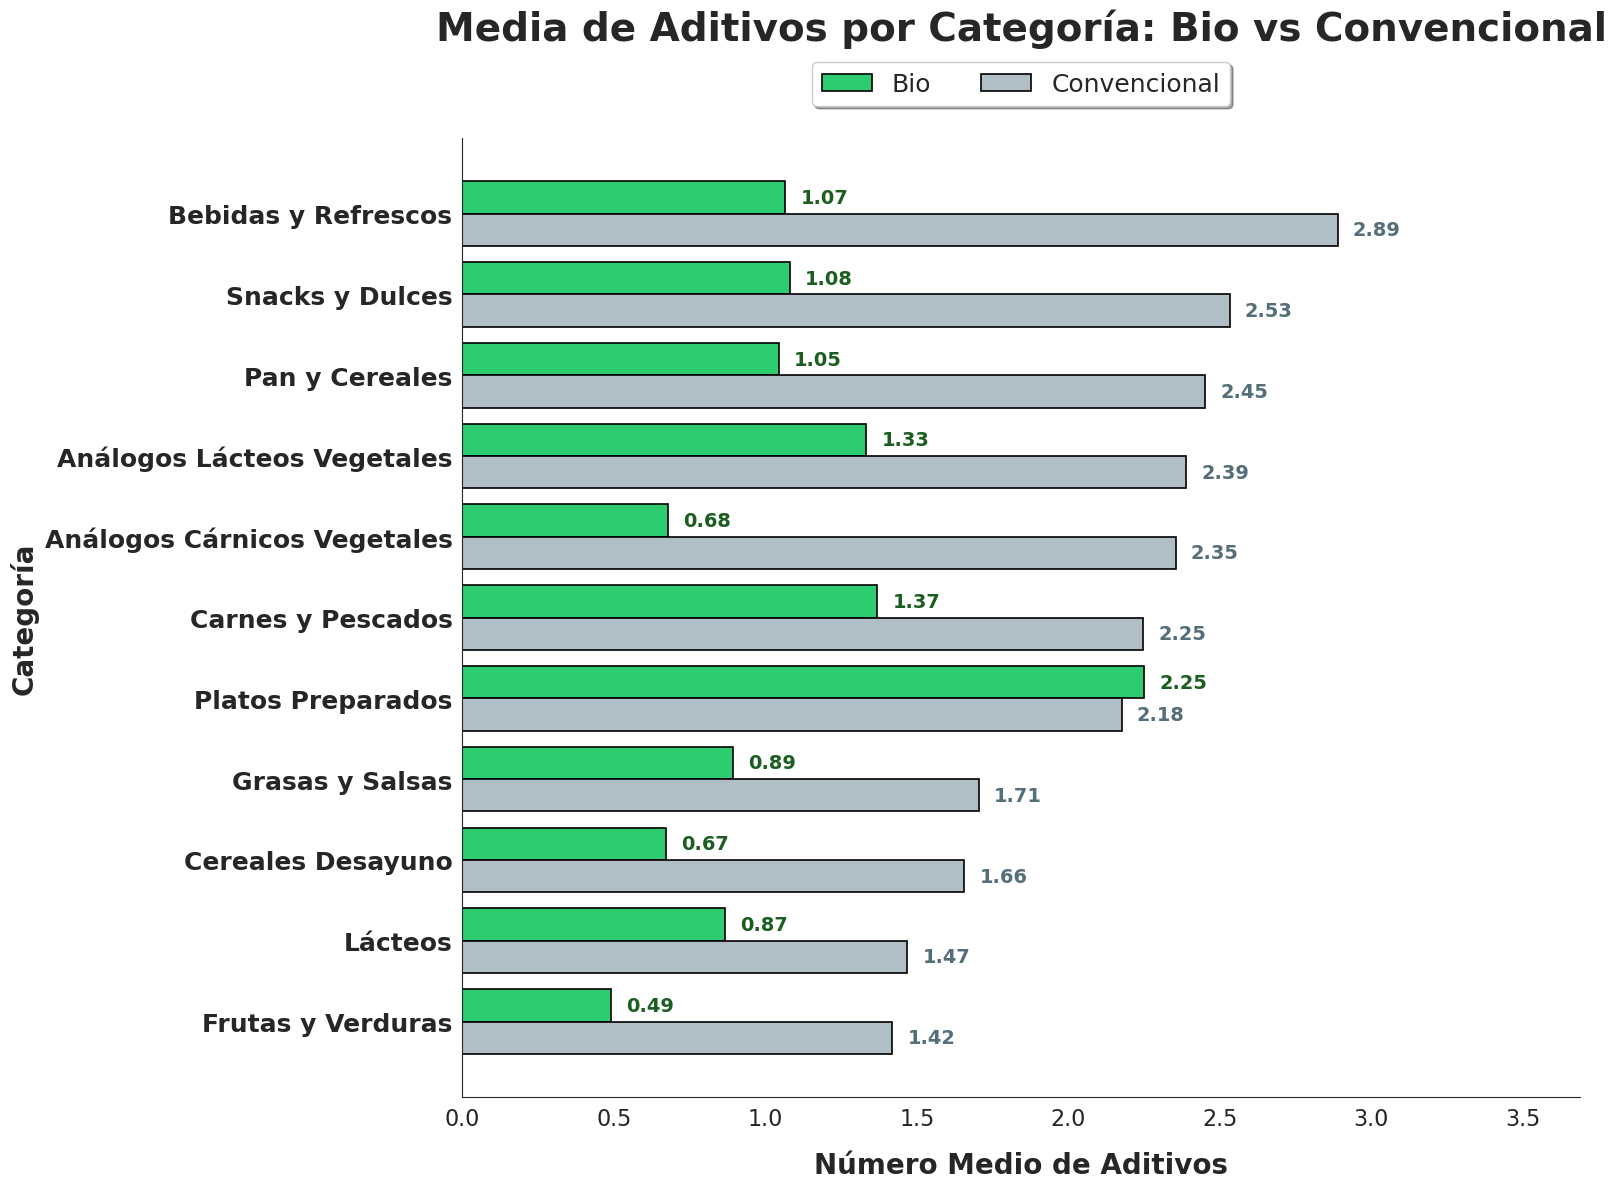

In [84]:

# 1. Preparación y Traducción

foods['category_es'] = foods['category_unified'].map(traduccion_cat).fillna(foods['category_unified'])

top_n = 20
categorias_top = foods['category_es'].value_counts().head(top_n).index
df_plot = foods[foods['category_es'].isin(categorias_top)].copy()

# 2. Cálculo de medias por categoría y tipo
stats_cat = df_plot.groupby(['category_es', 'is_bio'])['additive_count'].mean().unstack(fill_value=0)
stats_cat.columns = ['Convencional', 'Bio']
stats_cat = stats_cat.sort_values(by='Convencional', ascending=True) # Ordenamos para mejor lectura

# 3. Visualización
plt.figure(figsize=(16, 12))
y = range(len(stats_cat))
width = 0.4

# Bio en color, Convencional en gris
plt.barh([i + width/2 for i in y], stats_cat['Bio'], width, label='Bio', color='#2ecc71', edgecolor='black', linewidth=1.2)
plt.barh([i - width/2 for i in y], stats_cat['Convencional'], width, label='Convencional', color='#B0BEC5', edgecolor='black', linewidth=1.2)

# Fuentes y Etiquetas (MAXIMIZADAS)
plt.title('Media de Aditivos por Categoría: Bio vs Convencional', fontsize=28, fontweight='bold', pad=70)
plt.xlabel('Número Medio de Aditivos', fontsize=20, fontweight='bold', labelpad=15)
plt.ylabel('Categoría', fontsize=20, fontweight='bold')
plt.yticks(y, stats_cat.index, fontsize=18, fontweight='bold')
plt.xticks(fontsize=16)

# Leyenda arriba centrada
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=2, fontsize=18, frameon=True, shadow=True)

# Anotaciones de los valores al final de las barras
for i, (conv, bio) in enumerate(zip(stats_cat['Convencional'], stats_cat['Bio'])):
    plt.text(conv + 0.05, i - width/2, f'{conv:.2f}', va='center', fontsize=14, fontweight='bold', color='#546e7a')
    plt.text(bio + 0.05, i + width/2, f'{bio:.2f}', va='center', fontsize=14, fontweight='bold', color='#1b5e20')

plt.xlim(0, stats_cat.max().max() + 0.8)
sns.despine()
plt.tight_layout()
plt.show()

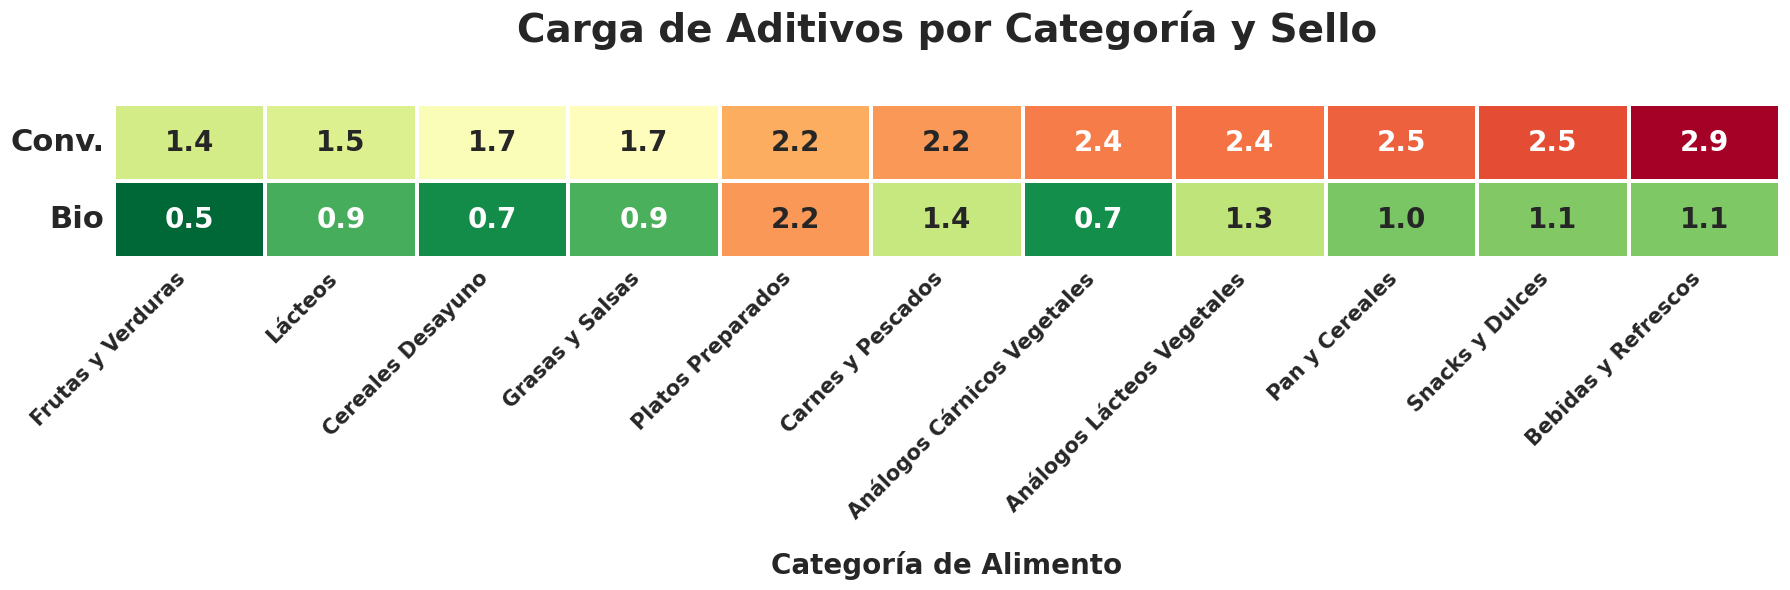

In [85]:
# --- HEATMAP DE ADITIVOS ---
plt.figure(figsize=(18, 6))

# 1. Preparamos los datos con nombres acortados
df_heatmap = stats_cat.T.copy()
df_heatmap.index = ['Conv.', 'Bio'] 

# 2. Dibujamos el heatmap
# fmt='.1f' añade un decimal
sns.heatmap(df_heatmap, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn_r', 
            cbar=False, 
            annot_kws={"size": 20, "weight": "bold"}, 
            linewidths=1.5)

# 3. Estética y Fuentes
plt.title('Carga de Aditivos por Categoría y Sello', fontsize=28, fontweight='bold', pad=45)
plt.xlabel('Categoría de Alimento', fontsize=20, fontweight='bold', labelpad=20)
plt.ylabel('', fontsize=20) 

# 4. Configuración de los ejes
plt.xticks(rotation=45, ha='right', fontsize=15, fontweight='bold')

# rotation=0 deja las etiquetas "Conv." y "Bio" en horizontal
plt.yticks(rotation=0, fontsize=22, fontweight='bold')

plt.tight_layout()

plt.savefig('../images/02_h02/2.5_heatmap_aditivos_bio.png', bbox_inches='tight', dpi=300)
plt.show()